## Analysis of Customer Data

The customer dataset was analyzed using customer lifetime value (CLV), income, age, and purchasing behavior. Customers were grouped into age categories to identify trends across demographic segments.

The analysis showed differences in average CLV among age groups, indicating that some age segments generate more long-term value than others. The scatter plot of income versus CLV suggests that higher income does not always translate directly into higher customer value, indicating that purchasing frequency plays an important role in determining CLV.

The correlation heatmap revealed the relationships between income, purchase frequency, average purchase value, and CLV. Customer lifetime value was most strongly influenced by purchase frequency and average purchase value.

Based on these findings, the company should focus its marketing efforts on the highest-value customer segments, particularly customers in the top 10% of CLV. Retention programs and personalized promotions could further increase customer value and reduce churn risk.

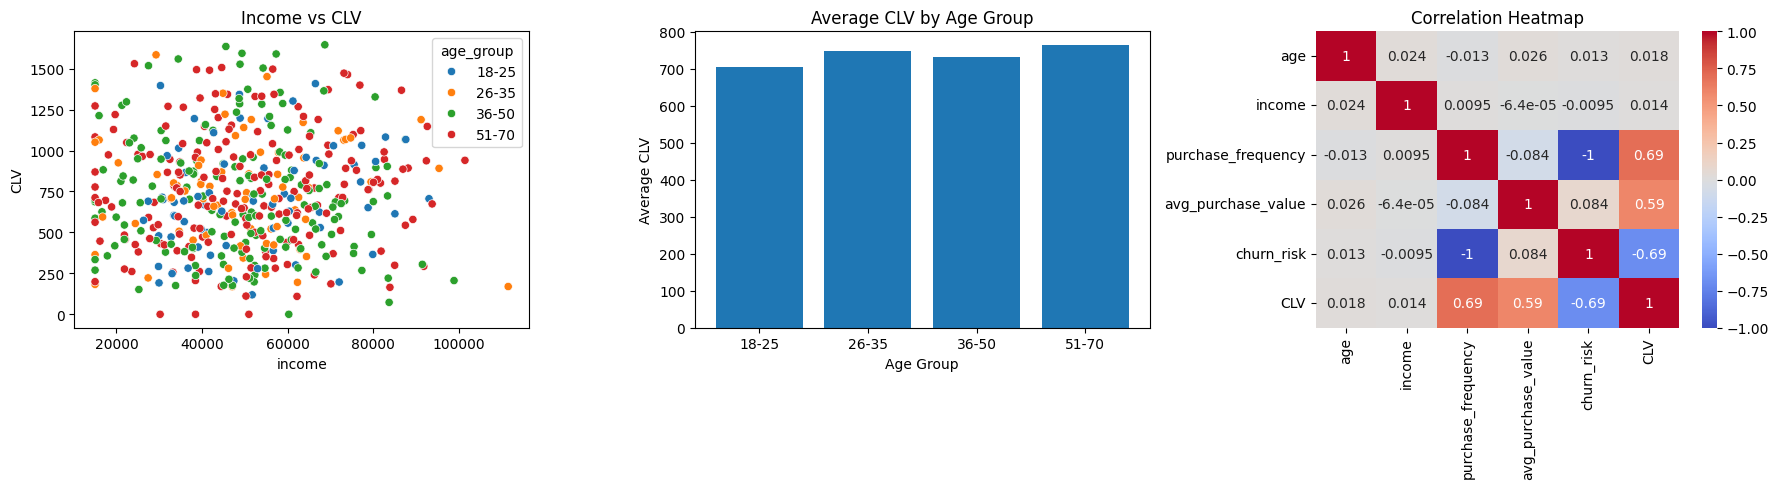

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot: Income vs CLV
sns.scatterplot(data=customers, x="income", y="CLV", hue="age_group", ax=axes[0])

axes[0].set_title("Income vs CLV")

# 2. Bar chart: Average CLV by age group
avg_clv = customers.groupby("age_group")["CLV"].mean()

axes[1].bar(avg_clv.index.astype(str), avg_clv.values)

axes[1].set_title("Average CLV by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Average CLV")

# 3. Correlation heatmap
numeric_data = customers.select_dtypes(include=np.number)

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", ax=axes[2])

axes[2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate churn risk
max_frequency = customers["purchase_frequency"].max()

customers["churn_risk"] = 1 - customers["purchase_frequency"] / max_frequency

# Calculate CLV
customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

# Create age groups
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
)

# Statistics by age group
summary = customers.groupby("age_group").agg(
    {"age": "count", "income": "mean", "CLV": ["mean", "sum"]}
)

print(summary)

# Top 10% customers
threshold = customers["CLV"].quantile(0.90)

top_customers = customers[customers["CLV"] >= threshold]

print("\nTop 10% Customers")
print(top_customers.head())

            age        income         CLV               
          count          mean        mean            sum
age_group                                               
18-25        69  51805.879852  704.492597   48609.989225
26-35        73  48747.148046  747.738562   54584.915035
36-50       160  48516.895668  732.796612  117247.457917
51-70       186  50713.163384  762.693498  141860.990683

Top 10% Customers
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  128

In [17]:
customers.head()

,age,income,purchase_frequency,avg_purchase_value
0,56,92443.123940,7,94.527456
1,69,70649.305211,2,100.932279
2,46,19612.600681,3,79.699876
3,32,40315.318543,2,130.137787
4,60,75338.222984,8,102.904845


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

# Exercise 7: Integration Challenge

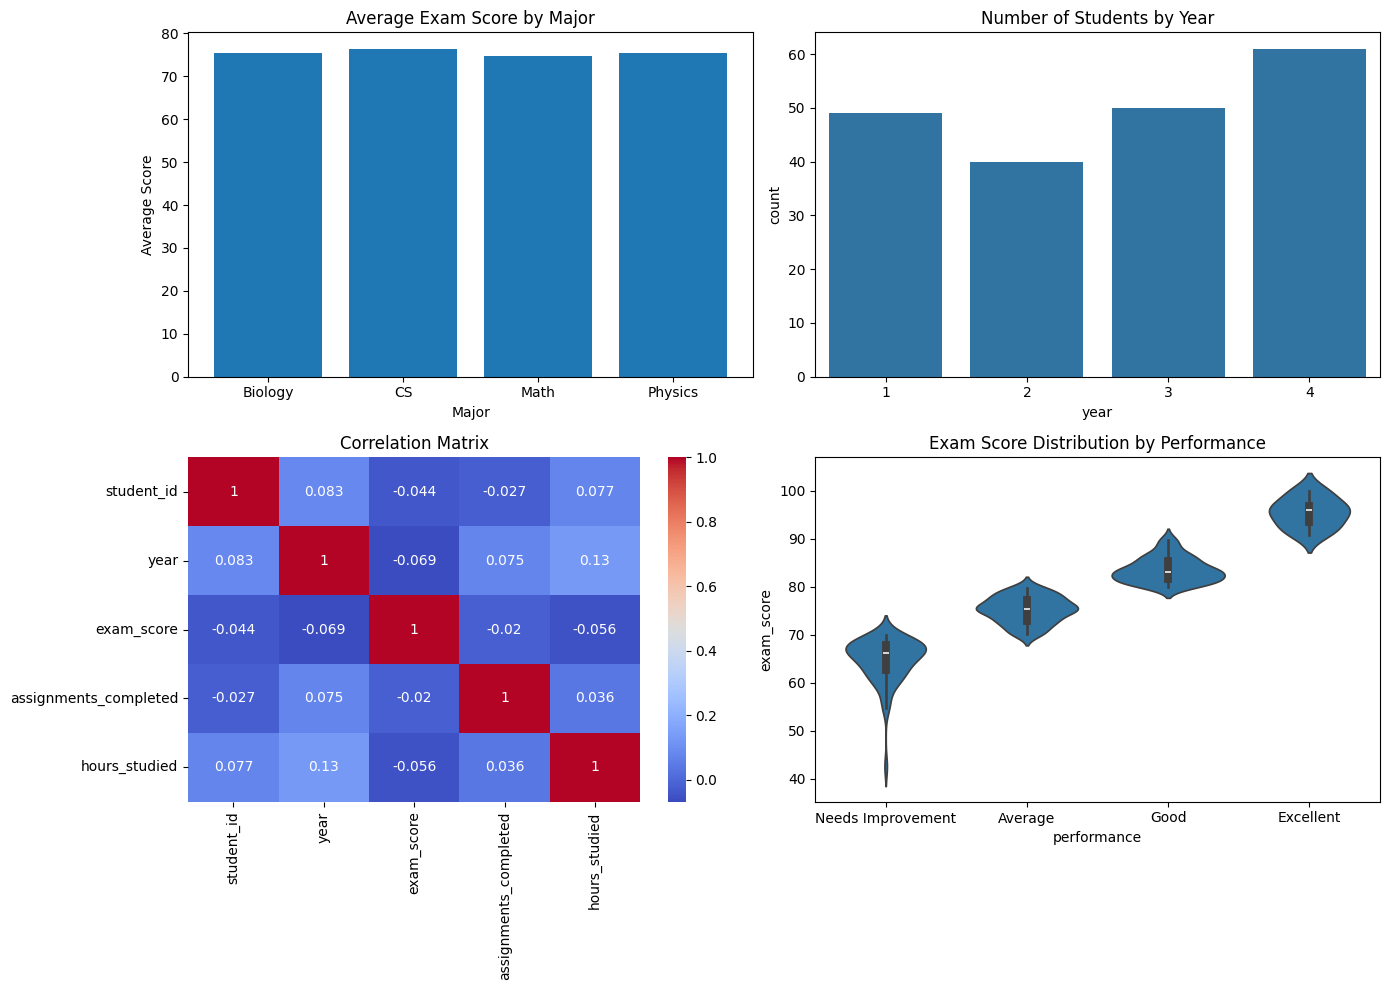

In [ ]:
# Task 3
# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby("major")["exam_score"].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")

# 2. Count plot: Students by year
sns.countplot(data=df, x="year", ax=axes[0, 1])

axes[0, 1].set_title("Number of Students by Year")

# 3. Heatmap: Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")

# 4. Violin plot: Exam score by performance category
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes[1, 1])

axes[1, 1].set_title("Exam Score Distribution by Performance")

plt.tight_layout()
plt.show()

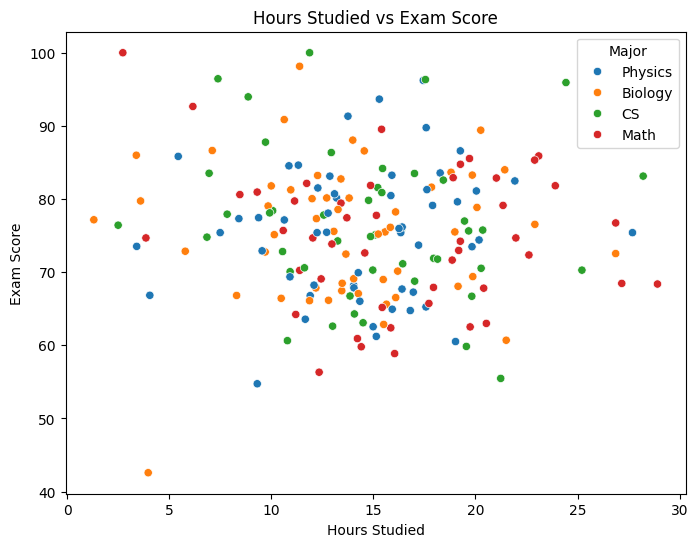

In [ ]:
# Task 2
# Scatter plot with regression line

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major")

sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")


plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.legend(title="Major")

plt.show()

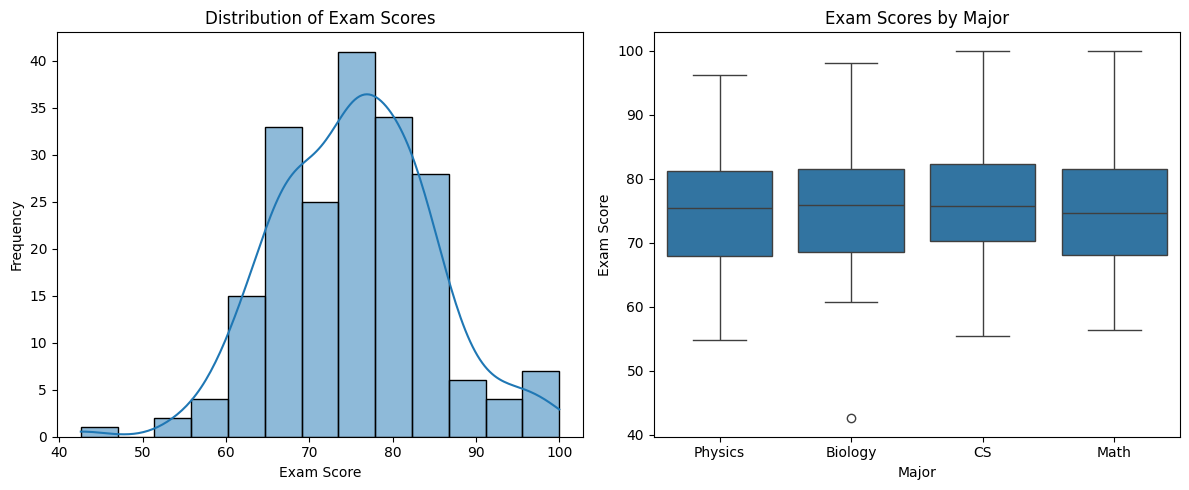

In [ ]:
# Task 1
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE
sns.histplot(df["exam_score"], kde=True, ax=axes[0])

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Box plot by major
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])

axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Exercise 6: Data Visualization

In [ ]:
# Task 3
# Statistics by major and year
summary = df.groupby(["major", "year"]).agg(
    {"student_id": "count", "exam_score": "mean", "hours_studied": "mean"}
)

summary.columns = ["Number_of_Students", "Average_Exam_Score", "Average_Hours_Studied"]

print("Summary by Major and Year:")
print(summary)

# Top 5 students by exam score
top_students = df.nlargest(5, "exam_score")

print("\nTop 5 Students:")
print(top_students[["student_id", "major", "exam_score"]])

# Pivot table
pivot_table = pd.pivot_table(
    df, values="exam_score", index="major", columns="year", aggfunc="mean"
)

print("\nPivot Table:")
print(pivot_table)


Summary by Major and Year:
              Number_of_Students  Average_Exam_Score  Average_Hours_Studied
major   year                                                               
Biology 1                     13           76.570059              12.677806
        2                     12           74.899613              13.426372
        3                     14           80.178476              14.486815
        4                     15           70.697689              14.253944
CS      1                     12           77.098194              13.039480
        2                      7           76.155936              13.995784
        3                      9           72.347626              15.039892
        4                     18           78.119997              16.275541
Math    1                     11           74.053167              19.001215
        2                      9           81.226714              12.345468
        3                     10           72.017537         

In [ ]:
# Task 2
# Average exam score by major
avg_scores = df.groupby("major")["exam_score"].mean()

print("Average Exam Score by Major:")
print(avg_scores)

# Major with highest average exam score
best_major = avg_scores.idxmax()

print("\nMajor with Highest Average Exam Score:")
print(best_major)

# Correlation between hours studied and exam score
correlation = df["hours_studied"].corr(df["exam_score"])

print("\nCorrelation between Hours Studied and Exam Score:")
print(correlation)

# Create performance categories
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
)

print("\nPerformance Categories:")
print(df[["exam_score", "performance"]].head())

Average Exam Score by Major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with Highest Average Exam Score:
CS

Correlation between Hours Studied and Exam Score:
-0.05598138347292445

Performance Categories:
   exam_score        performance
0   68.199753  Needs Improvement
1   77.322537            Average
2   77.930725            Average
3   67.856486  Needs Improvement
4   93.657745          Excellent


In [5]:
df.head()

,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,NaN
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370


In [ ]:
# Task 1
# Display basic information about the dataset
print(df.info())

# Count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for each major
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median for each year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

# Check missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing Values After Cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Exercise 5: Pandas Data Analysis

In [ ]:
# Task 1
import numpy as np

matrix1 = np.ones((5, 5))

matrix1[1:4, 1:4] = 0

print(matrix1)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
# Task 2
import numpy as np

np.random.seed(42)

random_data = np.random.randn(100, 3)

normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(normalized_data)

[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818398e-01]
 [ 1.14447901e+00  1.14403850e+00 -8.25443216e-01]
 [-4.88601912e-01  5.28126505e-

In [ ]:
# Task 3
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)

Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True coefficients:
[ 2.5 -1.2  3.7]


#Exercise 4: NumPy Array Operations